<a href="https://colab.research.google.com/github/beena24/Research_works/blob/main/pneumonia_glcm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split #importing to split the dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/pneu_final.csv')
data.head()

,image_name,ax,ay,az,aa,ab,ac,bx,by,bz,...,ea,eb,ec,fx,fy,fz,fa,fb,fc,class_label
0,1,4.423569,0.992795,0.240477,0.018769,0.000352,55.750405,4.456893,0.992689,0.241490,...,0.018769,0.000352,55.750405,4.061559,0.994111,0.256198,0.019326,0.000374,45.605601,0
1,2,5.762245,0.986552,0.232768,0.070098,0.004914,95.723462,5.890193,0.986184,0.234698,...,0.070098,0.004914,95.723462,5.377168,0.988877,0.247769,0.072237,0.005218,79.322354,0
2,3,4.470958,0.993155,0.286521,0.101962,0.010396,64.619089,4.549352,0.992881,0.288457,...,0.101962,0.010396,64.619089,4.166129,0.994185,0.302979,0.103654,0.010744,55.017180,0
3,4,4.492617,0.992983,0.239860,0.021398,0.000458,58.898893,4.485206,0.992978,0.245051,...,0.021398,0.000458,58.898893,4.119272,0.994291,0.260546,0.022335,0.000499,48.029847,0
4,5,5.816184,0.987962,0.260778,0.113232,0.012822,101.621054,6.054924,0.987073,0.260100,...,0.113232,0.012822,101.621054,5.558125,0.989494,0.270508,0.114936,0.013210,88.781899,0


In [ ]:
y=data.class_label
x=data.drop('class_label',axis=1)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4)
x_train.head()

,image_name,ax,ay,az,aa,ab,ac,bx,by,bz,...,ez,ea,eb,ec,fx,fy,fz,fa,fb,fc
501,502,5.460589,0.989809,0.247153,0.095009,0.009027,86.249819,5.420743,0.989883,0.251013,...,0.247153,0.095009,0.009027,86.249819,4.921803,0.991896,0.264684,0.097363,0.009480,68.834751
1062,1063,5.828997,0.985633,0.219836,0.073889,0.005460,91.794319,6.007185,0.985035,0.219082,...,0.219836,0.073889,0.005460,91.794319,5.607427,0.987485,0.228014,0.075711,0.005732,80.209162
2390,2391,7.789996,0.963800,0.163173,0.016216,0.000263,159.875810,8.530440,0.958939,0.152956,...,0.163173,0.016216,0.000263,159.875810,7.721093,0.966440,0.166048,0.016108,0.000259,150.106308
1613,1614,4.023370,0.986748,0.299174,0.024696,0.000610,60.525803,4.051037,0.986994,0.292745,...,0.299174,0.024696,0.000610,60.525803,3.685277,0.989254,0.307150,0.025099,0.000630,49.192363
1236,1237,5.891638,0.988572,0.212850,0.061102,0.003733,86.523461,5.790910,0.988978,0.217678,...,0.212850,0.061102,0.003733,86.523461,5.315205,0.991017,0.230130,0.063135,0.003986,68.234317


In [ ]:
from sklearn.calibration import calibration_curve
# Create classifiers
from sklearn.preprocessing import RobustScaler
#scaler = RobustScaler()
#x = scaler.fit_transfrom(x)
from sklearn import preprocessing
x_train = preprocessing.scale(x_train)
x_test = preprocessing.scale(x_test)


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.metrics import roc_curve

#ROC curve for classifiers
fpr1, tpr1, thresh1 = roc_curve(y_test, LR_y_pred[:], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, SVC_y_pred[:], pos_label=1)

#ROC curve for TPR=FPR
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)


In [ ]:
from sklearn.metrics import roc_auc_score

#AUC scores
auc_score4 = roc_auc_score(y_test,XGB_y_pred[:])
auc_score5 = roc_auc_score(y_test, LGBM_y_pred[:])
print("XGB:", auc_score2)
print("LGBM:", auc_score1)


In [ ]:
from sklearn.metrics import roc_curve

#ROC curve for classifiers
fpr1, tpr1, thresh1 = roc_curve(y_test, XGB_y_pred[:], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, LGBM_y_pred[:], pos_label=1)

#ROC curve for TPR=FPR
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

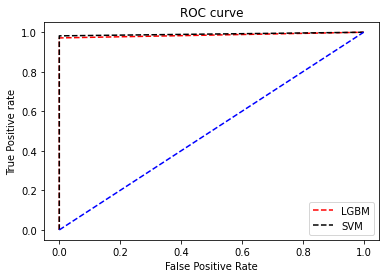

In [ ]:
plt.plot(fpr1, tpr1, linestyle='--',color='red', label='LGBM')
plt.plot(fpr2, tpr2, linestyle='--',color='black', label='SVM')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
#title
plt.title('ROC curve')
#x-label
plt.xlabel('False Positive Rate')
#y-label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC',dpi=300)
plt.show();


In [ ]:
from sklearn.metrics import roc_curve

#ROC curve for classifiers
fpr1, tpr1, thresh1 = roc_curve(y_test, result[:], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, XGB_y_pred[:], pos_label=1)

#ROC curve for TPR=FPR
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

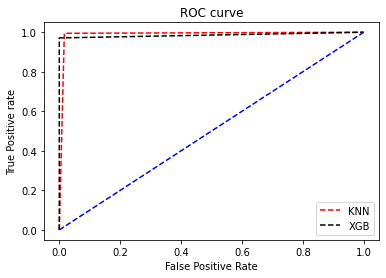

In [ ]:
plt.plot(fpr1, tpr1, linestyle='--',color='red', label='KNN')
plt.plot(fpr2, tpr2, linestyle='--',color='black', label='XGB')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
#title
plt.title('ROC curve')
#x-label
plt.xlabel('False Positive Rate')
#y-label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC',dpi=300)
plt.show();


In [ ]:
from sklearn.metrics import roc_curve

#ROC curve for classifiers
fpr1, tpr1, thresh1 = roc_curve(y_test, XGB_y_pred[:], pos_label=1)
fpr2, tpr2, thresh2 = roc_curve(y_test, LGBM_y_pred[:], pos_label=1)
fpr3, tpr3, thresh1 = roc_curve(y_test, gbc_pred[:], pos_label=1)
fpr4, tpr4, thresh4 = roc_curve(y_test, y_pred[:], pos_label=1)
#fpr5, tpr5, thresh1 = roc_curve(y_test, RFC_y_pred[:], pos_label=1)
#ROC curve for TPR=FPR
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

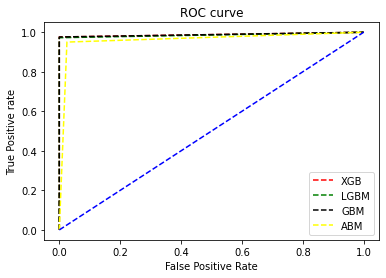

In [ ]:
plt.plot(fpr1, tpr1, linestyle='--',color='red', label='XGB')
plt.plot(fpr2, tpr2, linestyle='--',color='green', label='LGBM')
plt.plot(fpr3, tpr3, linestyle='--',color='black', label='GBM')
plt.plot(fpr4, tpr4, linestyle='--',color='yellow', label='ABM')
#plt.plot(fpr5, tpr5, linestyle='--',color='purple', label='RF')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
#title
plt.title('ROC curve')
#x-label
plt.xlabel('False Positive Rate')
#y-label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC',dpi=300)
plt.show();

In [ ]:
plt.plot(fpr1, tpr1, linestyle='--',color='green', label='Logistic Regression')
plt.plot(fpr2, tpr2, linestyle='--',color='green', label='SVM')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
#title
plt.title('ROC curve')
#x-label
plt.xlabel('False Positive Rate')
#y-label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC',dpi=300)
plt.show();

In [ ]:
import xgboost as xgb

In [ ]:
xgb_classifier = xgb.XGBClassifier()

In [ ]:
XGB_Model=xgb_classifier.fit(x_train,y_train)

In [ ]:
print(XGB_model.get_params())

NameError: name 'XGB_model' is not defined

In [ ]:
with open('XGB_Model.pkl', 'wb') as f5:
    pickle.dump(XGB_Model,f5)
    f5.close()

In [ ]:
from IPython.display import FileLink

FileLink(r'XGB_Model.pkl')

/content/XGB_Model.pkl

In [ ]:
XGB_y_pred=XGB_Model.predict(x_test)

In [ ]:
XGB_y_pred = XGB_Model.predict(x_test)

In [ ]:
XGB_acc_sc = accuracy_score(y_test, XGB_y_pred)
XGB_acc_sc

0.998114985862394

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False,title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    plt.figure(figsize=(8,8), dpi=100)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    savefilename = title+'.jpeg'

    plt.savefig(savefilename)

In [ ]:
cm_plot_labels = ['normal','covid','bacterial','viral']

In [ ]:
import itertools

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
import numpy as np


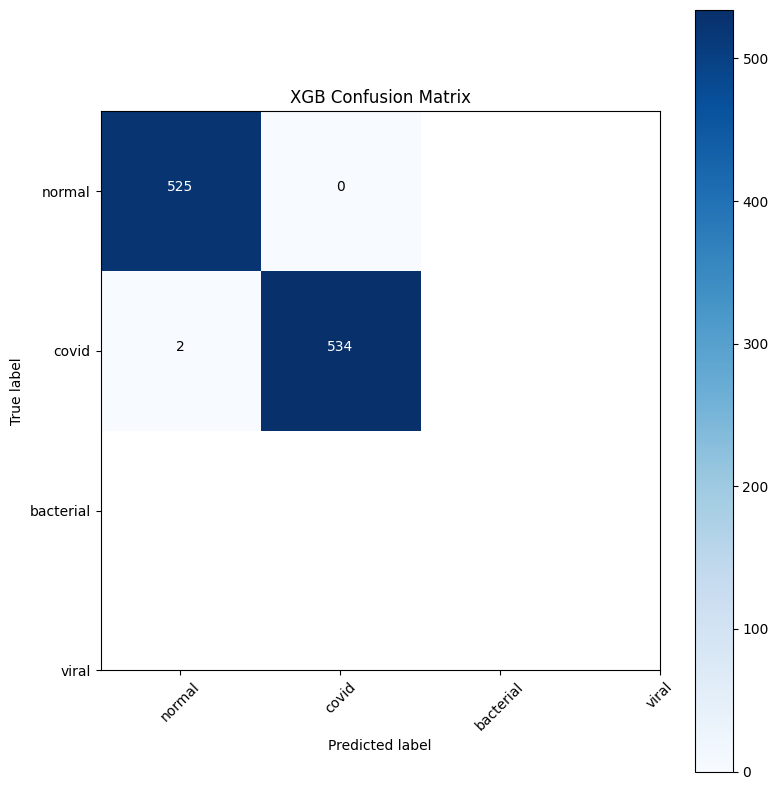

In [ ]:
cm_xgb = confusion_matrix(y_test, XGB_y_pred)
plot_confusion_matrix(cm_xgb, classes=cm_plot_labels, title='XGB Confusion Matrix')

In [ ]:
import lightgbm as lgb
clf = lgb.LGBMClassifier()
LGBM_Model=clf.fit(x_train, y_train)

In [ ]:
with open('LGBM_Model.pkl', 'wb') as f6:
    pickle.dump(LGBM_Model,f6)
    f6.close()

In [ ]:
from IPython.display import FileLink

FileLink(r'LGBM_Model.pkl')

/content/LGBM_Model.pkl

In [ ]:
LGBM_y_pred=LGBM_Model.predict(x_test)

In [ ]:
LGBM_acc_sc = accuracy_score(y_test, LGBM_y_pred)
LGBM_acc_sc

0.9915174363807728

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier()
gbc.fit(x_train,y_train)
gbc_pred=gbc.predict(x_test)

print(accuracy_score(y_test,gbc_pred))

0.9934024505183789


In [ ]:
!pip install catboost
!pip install scikit-learn
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.4 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


In [ ]:
import catboost as cb

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
from catboost import CatBoostClassifier

import numpy as np

# train data/labels

np.random.seed(7)

train_data = np.reshape(np.random.random(1000), (50, 20))

train_labels = np.round(np.random.random(50))

# train the model

model = CatBoostClassifier(verbose=False)

model.fit(x_train, y_train)

# get list of parameters

print(model.get_all_params())

{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'class_names': [0, 1], 'random_seed': 0, 'depth': 6, 'posterior_sampling': False, 'border_count': 254, 'classes_count': 0, 'auto_class_weights': 'None', 'sparse_features_conflict_fraction': 0, 'leaf_estimation_backtracking': 'AnyImprovement', 'best_model_min_trees': 1, 'model_shrink_rate': 0, 'min_data_in_leaf': 1, 'loss_function': 'Logloss', 'learning_rate': 0.012562000192701817, 'score_function': 'Cos

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
from sklearn.svm import SVC
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
svc=SVC(probability=True, kernel='linear')


In [ ]:
abc =AdaBoostClassifier(n_estimators=100, base_estimator=svc,learning_rate=1)

In [ ]:
model = abc.fit(x_train, y_train)

#Predict the response for test dataset
y_pred = model.predict(x_test)


# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.9622997172478793


>LogisticRegression: ideal=0.840, cv=0.850
>RidgeClassifier: ideal=0.830, cv=0.830
>SGDClassifier: ideal=0.790, cv=0.750
>PassiveAggressiveClassifier: ideal=0.840, cv=0.790
>KNeighborsClassifier: ideal=0.760, cv=0.770
>DecisionTreeClassifier: ideal=0.720, cv=0.670
>ExtraTreeClassifier: ideal=0.670, cv=0.680
>LinearSVC: ideal=0.840, cv=0.830
>SVC: ideal=0.900, cv=0.880
>GaussianNB: ideal=0.730, cv=0.720
>AdaBoostClassifier: ideal=0.740, cv=0.740
>BaggingClassifier: ideal=0.780, cv=0.680
>RandomForestClassifier: ideal=0.810, cv=0.720
>ExtraTreesClassifier: ideal=0.830, cv=0.850
>GaussianProcessClassifier: ideal=0.790, cv=0.760
>GradientBoostingClassifier: ideal=0.810, cv=0.810
>LinearDiscriminantAnalysis: ideal=0.830, cv=0.830
>QuadraticDiscriminantAnalysis: ideal=0.860, cv=0.700
Correlation: 0.717


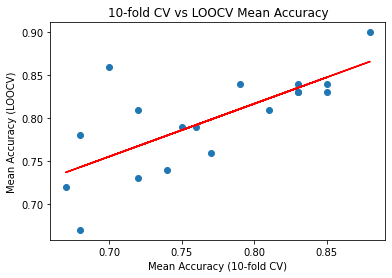

In [ ]:
from numpy import mean
from numpy import isnan
from numpy import asarray
from numpy import polyfit
from scipy.stats import pearsonr
from matplotlib import pyplot
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# create the dataset
def get_dataset(n_samples=100):
	x, y = make_classification(n_samples=n_samples, n_features=20, n_informative=15, n_redundant=5, random_state=1)
	return x, y

# get a list of models to evaluate
def get_models():
	models = list()
	models.append(LogisticRegression())
	models.append(RidgeClassifier())
	models.append(SGDClassifier())
	models.append(PassiveAggressiveClassifier())
	models.append(KNeighborsClassifier())
	models.append(DecisionTreeClassifier())
	models.append(ExtraTreeClassifier())
	models.append(LinearSVC())
	models.append(SVC())
	models.append(GaussianNB())
	models.append(AdaBoostClassifier())
	models.append(BaggingClassifier())
	models.append(RandomForestClassifier())
	models.append(ExtraTreesClassifier())
	models.append(GaussianProcessClassifier())
	models.append(GradientBoostingClassifier())
	models.append(LinearDiscriminantAnalysis())
	models.append(QuadraticDiscriminantAnalysis())
	return models

# evaluate the model using a given test condition
def evaluate_model(cv, model):
	# get the dataset
	x, y = get_dataset()
	# evaluate the model
	scores = cross_val_score(model, x, y, scoring='accuracy', cv=cv, n_jobs=-1)
	# return scores
	return mean(scores)

# define test conditions
ideal_cv = LeaveOneOut()
cv = KFold(n_splits=10, shuffle=True, random_state=1)
# get the list of models to consider
models = get_models()
# collect results
ideal_results, cv_results = list(), list()
# evaluate each model
for model in models:
	# evaluate model using each test condition
	cv_mean = evaluate_model(cv, model)
	ideal_mean = evaluate_model(ideal_cv, model)
	# check for invalid results
	if isnan(cv_mean) or isnan(ideal_mean):
		continue
	# store results
	cv_results.append(cv_mean)
	ideal_results.append(ideal_mean)
	# summarize progress
	print('>%s: ideal=%.3f, cv=%.3f' % (type(model).__name__, ideal_mean, cv_mean))
# calculate the correlation between each test condition
corr, _ = pearsonr(cv_results, ideal_results)
print('Correlation: %.3f' % corr)
# scatter plot of results
pyplot.scatter(cv_results, ideal_results)
# plot the line of best fit
coeff, bias = polyfit(cv_results, ideal_results, 1)
line = coeff * asarray(cv_results) + bias
pyplot.plot(cv_results, line, color='r')
# label the plot
pyplot.title('10-fold CV vs LOOCV Mean Accuracy')
pyplot.xlabel('Mean Accuracy (10-fold CV)')
pyplot.ylabel('Mean Accuracy (LOOCV)')
# show the plot
pyplot.show()

In [ ]:
cm_plot_labels = ['pneumonia','normal']

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import itertools

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False,title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """

    plt.figure(figsize=(8,8), dpi=100)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    savefilename = title+'.png'

    plt.savefig(savefilename)

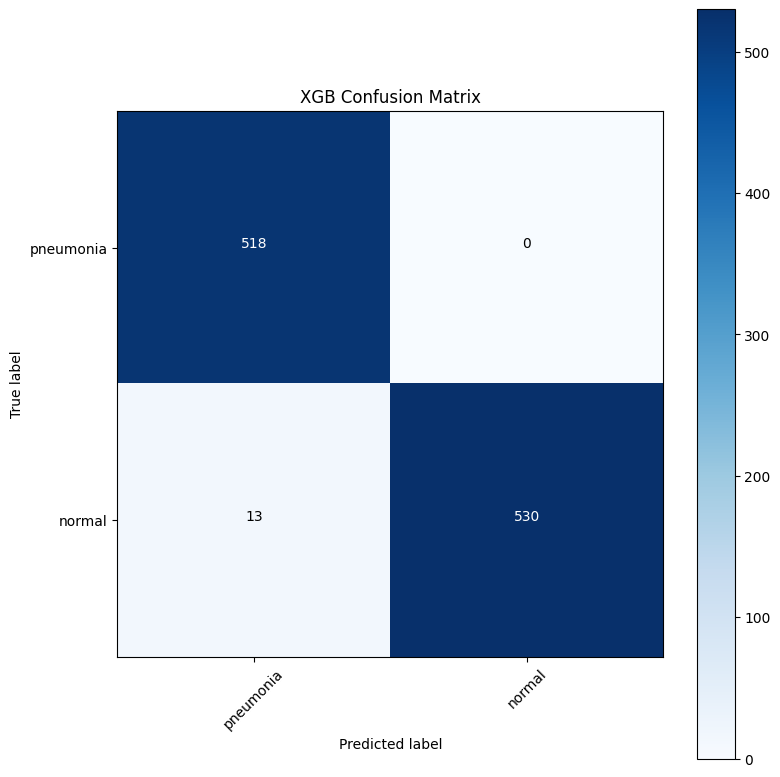

In [ ]:
cm_svc = confusion_matrix(y_test, XGB_y_pred)
plot_confusion_matrix(cm=cm_svc, classes=cm_plot_labels, title='XGB Confusion Matrix')

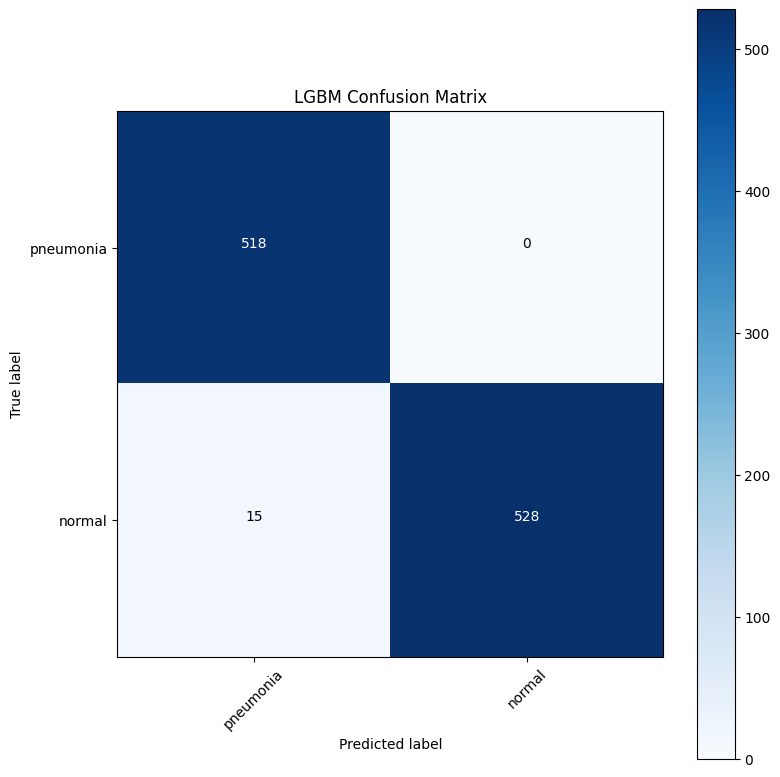

In [ ]:
cm_rf = confusion_matrix(y_test, LGBM_y_pred)
plot_confusion_matrix(cm=cm_rf, classes=cm_plot_labels, title='LGBM Confusion Matrix')

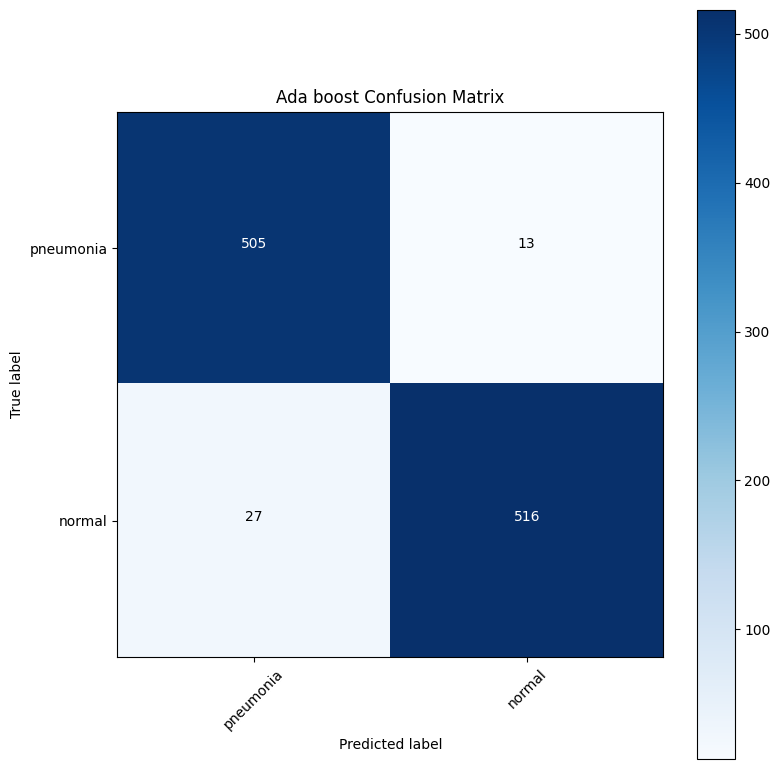

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm=cm_knn, classes=cm_plot_labels, title='Ada boost Confusion Matrix')

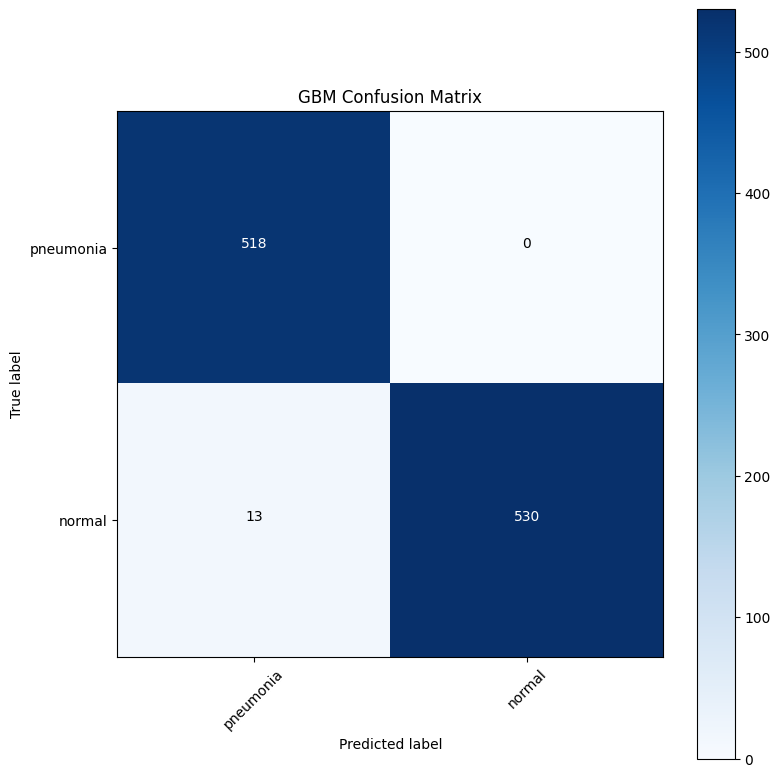

In [ ]:
cm_xgb = confusion_matrix(y_test, gbc_pred)
plot_confusion_matrix(cm=cm_xgb, classes=cm_plot_labels, title='GBM Confusion Matrix')

In [ ]:
from sklearn.metrics import classification_report


In [ ]:
print(classification_report(y_test, LGBM_y_pred))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99       518
           1       1.00      0.97      0.99       543

    accuracy                           0.99      1061
   macro avg       0.99      0.99      0.99      1061
weighted avg       0.99      0.99      0.99      1061



In [ ]:
print(classification_report(y_test, gbc_pred))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       518
           1       1.00      0.98      0.99       543

    accuracy                           0.99      1061
   macro avg       0.99      0.99      0.99      1061
weighted avg       0.99      0.99      0.99      1061



In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       518
           1       0.98      0.95      0.96       543

    accuracy                           0.96      1061
   macro avg       0.96      0.96      0.96      1061
weighted avg       0.96      0.96      0.96      1061



In [ ]:
print(classification_report(y_test, XGB_y_pred))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       518
           1       1.00      0.98      0.99       543

    accuracy                           0.99      1061
   macro avg       0.99      0.99      0.99      1061
weighted avg       0.99      0.99      0.99      1061



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
import numpy as np

x = np.array([-2.2, -1.4, -.8, .2, .4, .8, 1.2, 2.2, 2.9, 4.6])
y = np.array([0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

logr = LogisticRegression(solver='lbfgs')
logr.fit(x_train.reshape(-1, 1), y_train)

y_pred = logr.predict_proba(x_train.reshape(-1, 1))[:, 1].ravel()
loss = log_loss(y_train, y_pred)

print('x = {}'.format(x_train))
print('y = {}'.format(y_train))
print('p(y) = {}'.format(np.round(y_pred, 2)))
print('Log Loss / Cross Entropy = {:.4f}'.format(loss))

In [ ]:
log_reg = LogisticRegression(random_state=123)

log_reg.fit(x_train, y_train)


LogisticRegression(random_state=123)

In [ ]:
y_preds = log_reg.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

print(y_preds[:15])
print(y_test[:15])

print('Test Accuracy     : {:.3f}'.format(accuracy_score(y_test, y_preds)))
print('Test Accuracy     : {:.3f}'.format(log_reg.score(x_test, y_test))) ## Score method also evaluates accuracy for classification models.
print('Training Accuracy : {:.3f}'.format(log_reg.score(x_train, y_train)))

[1 1 0 1 1 1 1 1 0 1 1 1 0 0 1]
2297    1
2393    1
40      0
2448    1
2054    1
1822    1
2289    1
2343    1
506     0
1695    1
2361    1
1953    1
205     0
1198    0
2628    1
Name: class_label, dtype: int64
Test Accuracy     : 0.992
Test Accuracy     : 0.992
Training Accuracy : 0.992


In [ ]:
!pip install scikit-plot
from scikitplot.estimators import plot_feature_importances
from scikitplot.metrics import plot_confusion_matrix, plot_roc

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
pip install scikitplot

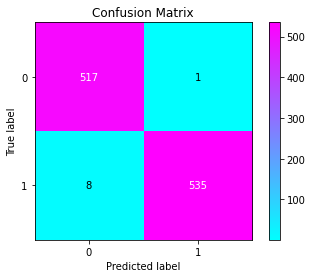

In [ ]:
import scikitplot as skplt

skplt.metrics.plot_confusion_matrix(y_test, y_preds,
                                    normalize=False,
                                    title="Confusion Matrix",
                                    cmap="cool",
                                    );

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

#fpr, tpr, thresholds = roc_curve(Y_test, log_reg.predict_proba(X_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, log_reg.decision_function(x_test))

#auc = roc_auc_score(Y_test, log_reg.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test, log_reg.decision_function(x_test))

acc = log_reg.score(x_test, y_test)

print("False Positive Rates : {}".format(fpr))
print("True  Positive Rates : {}".format(tpr))
print("Threshols            : {}".format(thresholds))
print("Accuracy             : {:.3f}".format(acc))
print("AUC                  : {:.3f}".format(auc))

False Positive Rates : [0.         0.         0.         0.0019305  0.0019305  0.003861
 0.003861   0.01351351 0.01351351 0.01544402 0.01544402 1.        ]
True  Positive Rates : [0.         0.00184162 0.91528545 0.91528545 0.98710866 0.98710866
 0.9907919  0.9907919  0.99815838 0.99815838 1.         1.        ]
Threshols            : [ 21.35391557  20.35391557   1.9365221    1.93251347  -0.03024944
  -0.10013566  -0.3498156   -1.06532507  -1.3484233   -1.46134615
  -1.67191218 -15.0750127 ]
Accuracy             : 0.992
AUC                  : 1.000


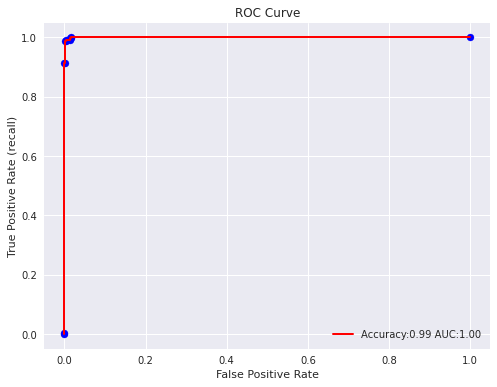

In [ ]:
with plt.style.context(('ggplot','seaborn')):
    plt.figure(figsize=(8,6))
    plt.scatter(fpr, tpr, c='blue')
    plt.plot(fpr, tpr, label="Accuracy:%.2f AUC:%.2f" % (acc, auc), linewidth=2, c='red')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (recall)")
    plt.title('ROC Curve')
    plt.legend(loc='best');

/usr/local/lib/python3.8/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.
  warnings.warn(msg, category=FutureWarning)


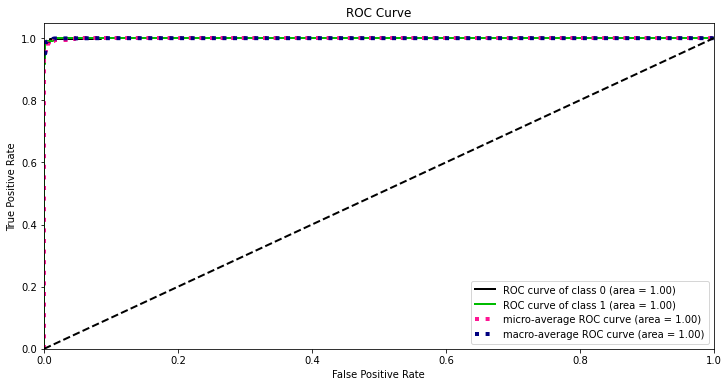

In [ ]:
skplt.metrics.plot_roc_curve(y_test, log_reg.predict_proba(x_test),
                             title="ROC Curve", figsize=(12,6));


In [ ]:
from sklearn.metrics import precision_recall_curve, auc,average_precision_score

#precision, recall, thresholds = precision_recall_curve(Y_test, log_reg.predict_proba(X_test)[:,1])
precision, recall, thresholds = precision_recall_curve(y_test, log_reg.decision_function(x_test))

acc = log_reg.score(x_test, y_test)

p_auc = auc(recall, precision)

print("Precision : {}".format(precision))
print("Recall    : {}".format(recall))
print("Threshols : {}".format(thresholds))
print("Accuracy  : {:.3f}".format(acc))
print("AUC       : {:.3f}".format(p_auc))

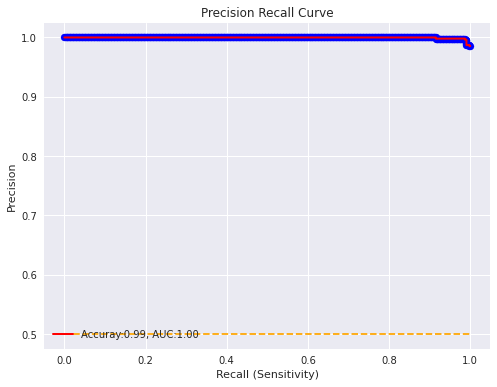

In [ ]:
with plt.style.context(('ggplot', 'seaborn')):
    plt.figure(figsize=(8,6))
    plt.scatter(recall, precision, c='blue')
    plt.plot(recall, precision, label="Accuray:%.2f, AUC:%.2f" % (acc, p_auc), linewidth=2, c='red')
    plt.hlines(0.5,0.0,1.0, linestyle='dashed', colors=['orange'])
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title('Precision Recall Curve')
    plt.legend(loc='best');